# Graph Analysis with NetworkX

This notebook covers basic graph analysis techniques including centrality measures, clustering, and community detection.

In [1]:
import networkx as nx
import matplotlib.pyplot as plt
import numpy as np
from collections import Counter

## Sample Social Network

Let's create a sample social network to analyze.

C:\Users\Soumyadipta\AppData\Local\Temp\ipykernel_35476\3646477411.py:26: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


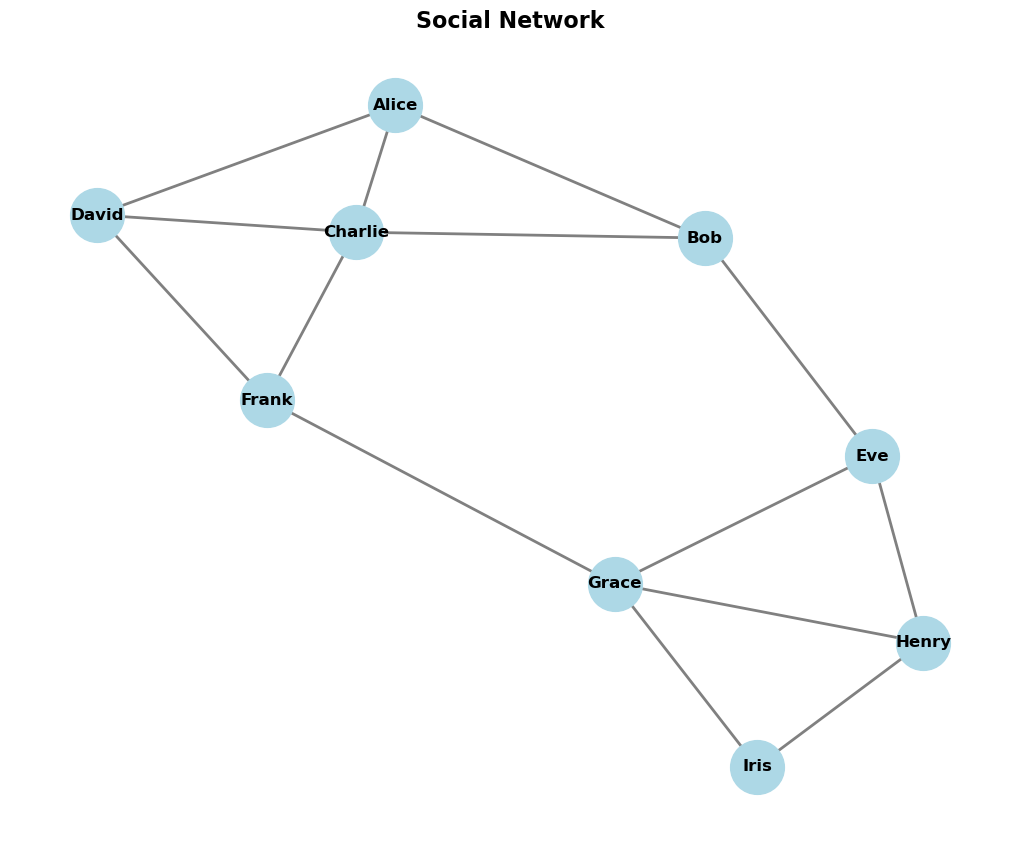

Nodes: 9
Edges: 14


In [2]:
# Create a sample social network
G = nx.Graph()

# Add edges (friendships)
edges = [
    ('Alice', 'Bob'), ('Alice', 'Charlie'), ('Alice', 'David'),
    ('Bob', 'Charlie'), ('Bob', 'Eve'),
    ('Charlie', 'David'), ('Charlie', 'Frank'),
    ('David', 'Frank'),
    ('Eve', 'Grace'), ('Eve', 'Henry'),
    ('Frank', 'Grace'),
    ('Grace', 'Henry'), ('Grace', 'Iris'),
    ('Henry', 'Iris')
]

G.add_edges_from(edges)

# Visualize
plt.figure(figsize=(10, 8))
pos = nx.spring_layout(G, seed=42)
nx.draw(G, pos, with_labels=True, node_color='lightblue',
        node_size=1500, font_size=12, font_weight='bold',
        edge_color='gray', width=2)
plt.title("Social Network", fontsize=16, fontweight='bold')
plt.axis('off')
plt.tight_layout()
plt.show()

print(f"Nodes: {G.number_of_nodes()}")
print(f"Edges: {G.number_of_edges()}")

## Basic Graph Properties

In [3]:
# Degree of each node
print("Degree of each node:")
for node in G.nodes():
    print(f"  {node}: {G.degree(node)}")

# Average degree
avg_degree = sum(dict(G.degree()).values()) / G.number_of_nodes()
print(f"\nAverage degree: {avg_degree:.2f}")

# Density
density = nx.density(G)
print(f"Graph density: {density:.3f}")

# Is the graph connected?
print(f"\nIs connected: {nx.is_connected(G)}")
print(f"Number of connected components: {nx.number_connected_components(G)}")

Degree of each node:
  Alice: 3
  Bob: 3
  Charlie: 4
  David: 3
  Eve: 3
  Frank: 3
  Grace: 4
  Henry: 3
  Iris: 2

Average degree: 3.11
Graph density: 0.389

Is connected: True
Number of connected components: 1


## Degree Distribution

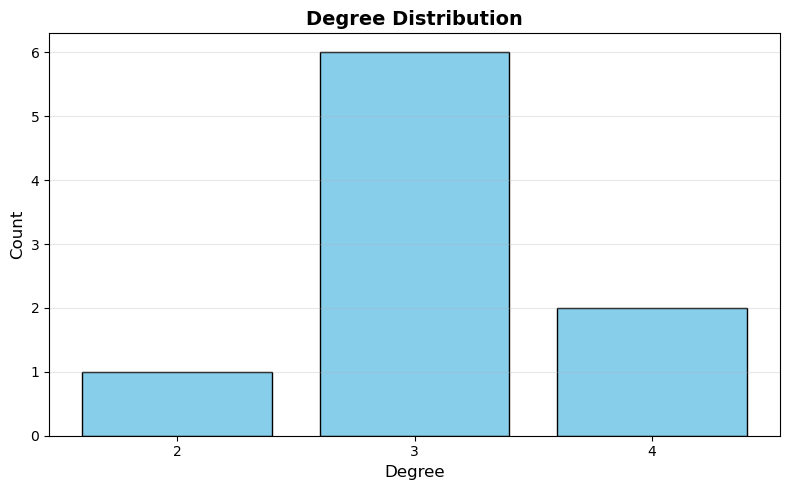

In [4]:
# Get degree sequence
degrees = [G.degree(n) for n in G.nodes()]
degree_counts = Counter(degrees)

# Plot degree distribution
plt.figure(figsize=(8, 5))
plt.bar(degree_counts.keys(), degree_counts.values(), color='skyblue', edgecolor='black')
plt.xlabel('Degree', fontsize=12)
plt.ylabel('Count', fontsize=12)
plt.title('Degree Distribution', fontsize=14, fontweight='bold')
plt.xticks(list(degree_counts.keys()))
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

## Centrality Measures

Centrality measures identify the most important nodes in a network.

### Degree Centrality

Measures the number of connections a node has.

In [5]:
degree_centrality = nx.degree_centrality(G)
print("Degree Centrality:")
for node, centrality in sorted(degree_centrality.items(), key=lambda x: x[1], reverse=True):
    print(f"  {node}: {centrality:.3f}")

Degree Centrality:
  Charlie: 0.500
  Grace: 0.500
  Alice: 0.375
  Bob: 0.375
  David: 0.375
  Eve: 0.375
  Frank: 0.375
  Henry: 0.375
  Iris: 0.250


### Betweenness Centrality

Measures how often a node lies on the shortest path between other nodes.

In [6]:
betweenness_centrality = nx.betweenness_centrality(G)
print("Betweenness Centrality:")
for node, centrality in sorted(betweenness_centrality.items(), key=lambda x: x[1], reverse=True):
    print(f"  {node}: {centrality:.3f}")

Betweenness Centrality:
  Grace: 0.307
  Frank: 0.250
  Eve: 0.190
  Bob: 0.179
  Charlie: 0.104
  Henry: 0.045
  David: 0.039
  Alice: 0.030
  Iris: 0.000


### Closeness Centrality

Measures how close a node is to all other nodes in the network.

In [7]:
closeness_centrality = nx.closeness_centrality(G)
print("Closeness Centrality:")
for node, centrality in sorted(closeness_centrality.items(), key=lambda x: x[1], reverse=True):
    print(f"  {node}: {centrality:.3f}")

Closeness Centrality:
  Frank: 0.615
  Grace: 0.615
  Bob: 0.571
  Charlie: 0.571
  Eve: 0.571
  David: 0.500
  Henry: 0.500
  Alice: 0.471
  Iris: 0.421


### Eigenvector Centrality

Measures influence based on connections to other important nodes.

In [8]:
eigenvector_centrality = nx.eigenvector_centrality(G)
print("Eigenvector Centrality:")
for node, centrality in sorted(eigenvector_centrality.items(), key=lambda x: x[1], reverse=True):
    print(f"  {node}: {centrality:.3f}")

Eigenvector Centrality:
  Charlie: 0.442
  David: 0.361
  Frank: 0.357
  Alice: 0.357
  Grace: 0.341
  Bob: 0.341
  Eve: 0.293
  Henry: 0.256
  Iris: 0.186


### Visualizing Centrality

C:\Users\Soumyadipta\AppData\Local\Temp\ipykernel_35476\1736355438.py:17: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


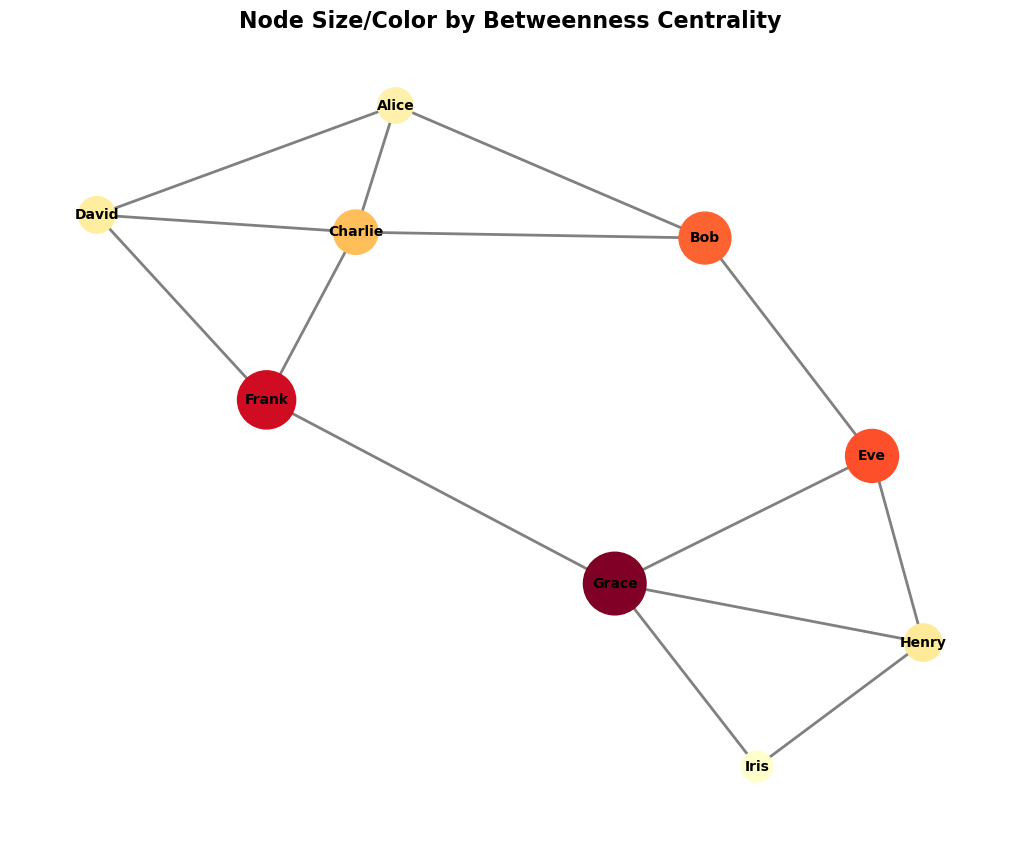

In [9]:
# Visualize betweenness centrality
plt.figure(figsize=(10, 8))
pos = nx.spring_layout(G, seed=42)

# Node size based on betweenness centrality
node_sizes = [5000 * betweenness_centrality[node] + 500 for node in G.nodes()]

# Node color based on betweenness centrality
node_colors = [betweenness_centrality[node] for node in G.nodes()]

nx.draw(G, pos, with_labels=True, node_size=node_sizes, node_color=node_colors,
        cmap='YlOrRd', font_size=10, font_weight='bold',
        edge_color='gray', width=2)

plt.title("Node Size/Color by Betweenness Centrality", fontsize=16, fontweight='bold')
plt.axis('off')
plt.tight_layout()
plt.show()

## Clustering

Clustering coefficient measures how much nodes tend to cluster together.

In [10]:
# Clustering coefficient for each node
clustering = nx.clustering(G)
print("Clustering Coefficient:")
for node, coef in sorted(clustering.items(), key=lambda x: x[1], reverse=True):
    print(f"  {node}: {coef:.3f}")

# Average clustering coefficient
avg_clustering = nx.average_clustering(G)
print(f"\nAverage clustering coefficient: {avg_clustering:.3f}")

Clustering Coefficient:
  Iris: 1.000
  Alice: 0.667
  David: 0.667
  Henry: 0.667
  Charlie: 0.500
  Bob: 0.333
  Eve: 0.333
  Frank: 0.333
  Grace: 0.333

Average clustering coefficient: 0.537


## Shortest Paths

In [11]:
# Shortest path between two nodes
source = 'Alice'
target = 'Iris'

shortest_path = nx.shortest_path(G, source, target)
path_length = nx.shortest_path_length(G, source, target)

print(f"Shortest path from {source} to {target}:")
print(f"  Path: {' -> '.join(shortest_path)}")
print(f"  Length: {path_length}")

# Average shortest path length
avg_path_length = nx.average_shortest_path_length(G)
print(f"\nAverage shortest path length: {avg_path_length:.3f}")

# Diameter (longest shortest path)
diameter = nx.diameter(G)
print(f"Diameter: {diameter}")

Shortest path from Alice to Iris:
  Path: Alice -> Bob -> Eve -> Grace -> Iris
  Length: 4

Average shortest path length: 1.889
Diameter: 4


## Community Detection

Identify groups of nodes that are more densely connected.

In [12]:
# Using greedy modularity optimization
from networkx.algorithms import community

communities = community.greedy_modularity_communities(G)

print(f"Number of communities: {len(communities)}")
for i, comm in enumerate(communities, 1):
    print(f"Community {i}: {sorted(comm)}")

Number of communities: 2
Community 1: ['Alice', 'Bob', 'Charlie', 'David', 'Frank']
Community 2: ['Eve', 'Grace', 'Henry', 'Iris']


C:\Users\Soumyadipta\AppData\Local\Temp\ipykernel_35476\2383484373.py:20: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


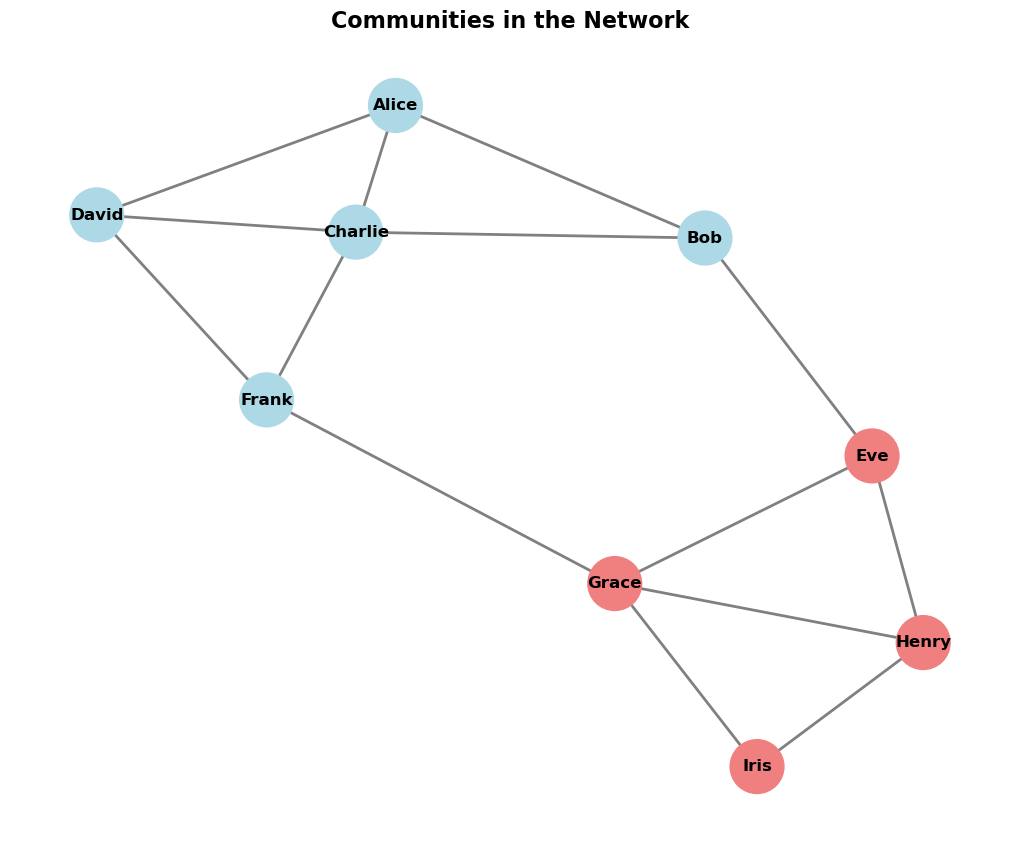

In [13]:
# Visualize communities
plt.figure(figsize=(10, 8))
pos = nx.spring_layout(G, seed=42)

# Color nodes by community
colors = ['lightblue', 'lightcoral', 'lightgreen', 'lightyellow', 'lightpink']
node_colors = []
for node in G.nodes():
    for i, comm in enumerate(communities):
        if node in comm:
            node_colors.append(colors[i % len(colors)])
            break

nx.draw(G, pos, with_labels=True, node_color=node_colors,
        node_size=1500, font_size=12, font_weight='bold',
        edge_color='gray', width=2)

plt.title("Communities in the Network", fontsize=16, fontweight='bold')
plt.axis('off')
plt.tight_layout()
plt.show()

## Exercise

Try analyzing the following:
1. Create a larger random network and compute its properties
2. Find the most central nodes using different centrality measures
3. Detect communities in a scale-free network (Barabási-Albert model)

In [14]:
# Your code here
